In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import sys
from urllib.error import HTTPError

from astropy import units as u
from astropy.coordinates import SkyCoord
import pickle
import CubeFunctions as cf

from scipy.interpolate import make_smoothing_spline

sys.path.append("/lustre/lrspec/users/4300/cube/gopreaux/src/caat/")
from SN import SN
from caat import SNCollection, GP, DataCube, GP3D, SNModel #,SN, GP3D, 
from caat.utils import WLE
import numpy as np
from sklearn.gaussian_process.kernels import Matern, RBF, WhiteKernel
import logging

logger = logging.getLogger()
logger.setLevel(logging.ERROR)

In [17]:
infos,datas,names_dict = cf.OSCtoCAATTables("SN2013bs",save=True,path = "/lustre/lrspec/users/4300/cube/Data/Phot")

[0.95989367 0.14607605]


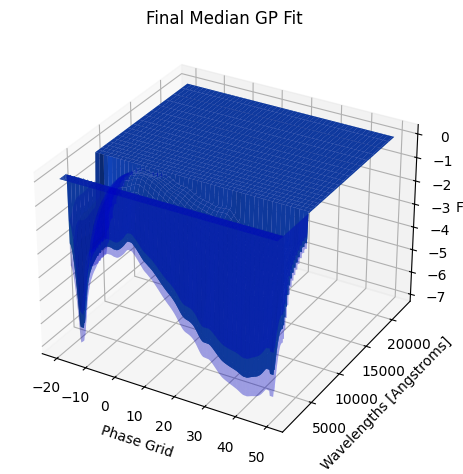

SN2011fe done!


In [18]:
models = []

kernel = RBF([np.log(10.0), np.log10(500.0)], (0.1, 3.0))
sn_to_normalize = SNCollection(sntype="Other", snsubtype = "SNIa")
filts = ['UVW2', 'UVM2', 'UVW1', 'U', 'B', 'g', 'c', 'V', 'r', 'o', 'i','z','y','J','H','K']
phasemin = -20
phasemax = 50
log_transform = 22
mangle_sed = True

for name in ["SN2011fe"]:
    sn_type = SNCollection([name])
    kernel = RBF([np.log(10.0), np.log10(500.0)], (0.1, 3.0))
    
    gp = GP3D(
        sn_type, 
        kernel, 
        filts,
        phasemin, 
        phasemax,
        set_to_normalize=sn_to_normalize,
        log_transform=log_transform,
        mangle_sed=mangle_sed
    )
    try:
        kernel_parameters = gp.optimize_hyperparams(subtract_polynomial=True)
    except ValueError:
        print(f'{name} has weird kernel')
    except IndexError:
        print(f'{name} returns error "list index out of range" during optimize parameters')
    # Let's look at the kernel hyperparameters
    optimized_kernel_hyperparams = np.asarray([np.median([k[i] for k in kernel_parameters]) for i in range(len(kernel_parameters[0]))])
    print(np.exp(optimized_kernel_hyperparams))
    if len(np.exp(optimized_kernel_hyperparams)) > 1:
        try:
            model = gp.predict(
                plot=False,
                subtract_polynomial=True,
            ) 
            print(f"{name} done!")
            models.append(model)
        except ValueError:
            print(f"{name} had error during modeling")
            continue
    else:
        print(f'{name} is weird')
        continue

In [19]:
#I need to make an array
dT1 = (1/24)*1.5 #90 min
dT2 = (1/24)*0.5 #30 min
wl1 = 5000
wl2 = 6400
times_wl1 = np.arange(-10,40,0.1)
times_wl2 = np.arange(-10,40,0.1)
phases = np.concatenate((times_wl1,times_wl2), axis=None)
wl1s = np.full(len(times_wl1),wl1)
wl2s = np.full(len(times_wl2),wl2)
wls = np.concatenate((wl1s,wl2s),axis=None)
phase_wl_array = np.vstack((np.log10(phases),np.log10(wls))).T

In [20]:
models[0].surface.iqr = np.abs(models[0].surface.iqr)

In [21]:
from scipy.interpolate import RegularGridInterpolator

interp_std = RegularGridInterpolator(
            (models[0].surface.phase_grid, models[0].surface.wl_grid), models[0].surface.iqr.T
        )

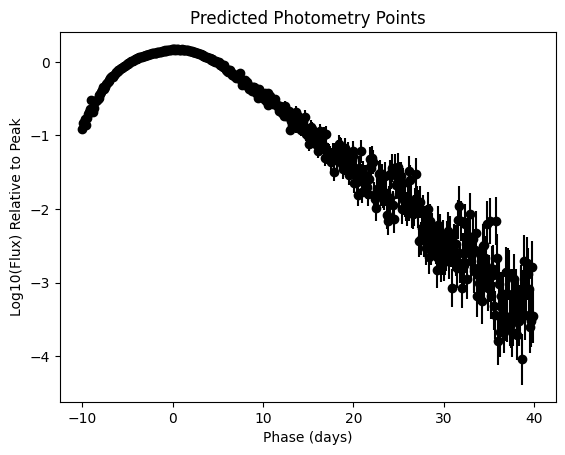

In [27]:
phases, pred, dev = models[0].predict_photometry_points(wl1s,times_wl1, show = True)

In [2]:
SS_info = pd.read_fwf("https://cdsarc.cds.unistra.fr/ftp/J/AJ/155/201/table3.dat", 
                      names = ["Name","RA","Dec","SN Type","z","Classifier","Discoverer","Tmax","Has LC?"],
                      colspecs = [[0,23],[24,36],[37,49],[50,52],[54,61],[63,74],[75,81],[81,86],[87,90]]                                                                      )
SS_info

,Name,RA,Dec,SN Type,z,Classifier,Discoverer,Tmax,Has LC?
0,CSS121006:232854+085452,23 28 54.48,+08 54 51.6,Ia,0.0800,D12b,D12c,56207,Yes
1,CSS121009:011101-172841,01 11 01.091,-17 28 42.28,Ia,0.0600,D12b,D12c,56220,Yes
2,CSS121114:090202+101800,09 02 02.420,+10 18 00.31,Ia,0.0420,G12,D12a,56252,Yes
3,CSS130218:092354+385837,09 23 54.52,+38 58 36.8,Ia,0.0500,D13b,D13a,56361,No
4,CSS130317:082848+293031,08 28 47.784,+29 30 30.85,Ia,0.0800,D13b,D13b,56370,No
...,...,...,...,...,...,...,...,...,...
69,iPTF13dge,05 03 35.091,+01 34 17.03,Ia,0.0158,C13b,C13b,56555,No
70,iPTF13dkj,23 08 50.737,+20 04 08.59,Ia,0.0300,C13a,C13a,56555,No
71,iPTF13dkl,23 44 57.999,+03 23 40.07,Ia,0.0400,C13a,C13a,56556,Yes
72,iPTF13dkx,01 20 53.115,+03 20 23.65,Ia,0.0300,C13a,C13a,56561,Yes


In [3]:
SS_info["Name"] = SS_info["Name"].str.replace(" ","")
SS_info["Name"]

0     CSS121006:232854+085452
1     CSS121009:011101-172841
2     CSS121114:090202+101800
3     CSS130218:092354+385837
4     CSS130317:082848+293031
               ...           
69                  iPTF13dge
70                  iPTF13dkj
71                  iPTF13dkl
72                  iPTF13dkx
73                  iPTF13ebh
Name: Name, Length: 74, dtype: object

In [4]:
SNe = []
for name in SS_info["Name"]:
    try:
        infos,datas,names_dict = cf.OSCtoCAATTables(name,save=False)
    except HTTPError:
        names_dict = "Not found; HTTPError"
    except KeyError:
        names_dict = "no category 'time'"
    print(name, names_dict)
    if len(names_dict) == 1:
        infos,datas,names_dict = cf.OSCtoCAATTables(name,save=True, path = "/lustre/lrspec/users/4300/cube/Data/Phot")
        SNe.append(name)

CSS121006:232854+085452 []
CSS121009:011101-172841 []
CSS121114:090202+101800 []
CSS130218:092354+385837 []
CSS130317:082848+293031 []
LSQ12fhs []
LSQ12fmx []
LSQ12fuk ['LSQ12fuk']
LSQ12gef ['LSQ12gef']
LSQ13cmt []
LSQ13crf ['LSQ13crf']
LSQ13cwp []
PS1-12bwh []
PS1-13dkh []
PSNJ07250042+2347030 Not found; HTTPError
PTF11moy []
PTF11mty ['PTF11mty']
PTF11owc []
PTF11qmo ['PTF11qmo']
PTF11qpc ['PTF11qpc']
PTF11qri []
PTF11qzq []
PTF12iiq []
PTF12ikt []
PTF13asv Not found; HTTPError
PTF13ayw []
PTF13dad []
PTF13ddg []
SN2011fe ['SN2011fe']
SN2011fs ['SN2011fs']
SN2011gf []
SN2011gy []
SN2011ha []
SN2011hb ['SN2011hb']
SN2011hk ['SN2011hk']
SN2011ho []
SN2011hr []
SN2011io []
SN2011iu []
SN2011iy []
SN2011jh []
SN2012bh ['SN2012bh']
SN2012bm []
SN2012bo no category 'time'
SN2012bp []
SN2012cg ['SN2012cg']
SN2012em []
SN2012et []
SN2012fb []
SN2012fk []
SN2012fm []
SN2012fr ['SN2012fr']
SN2012gm []
SN2012go []
SN2013ar []
SN2013be []
SN2013bo []
SN2013bq []
SN2013bs ['SN2013bs']
SN2013bt ['

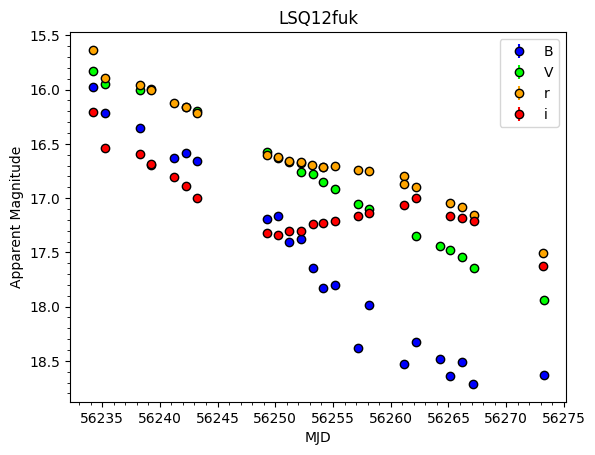

Skip? (y/n) y


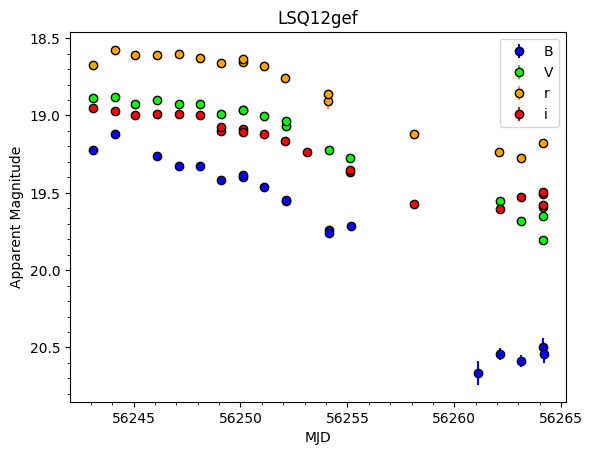

Skip? (y/n) y


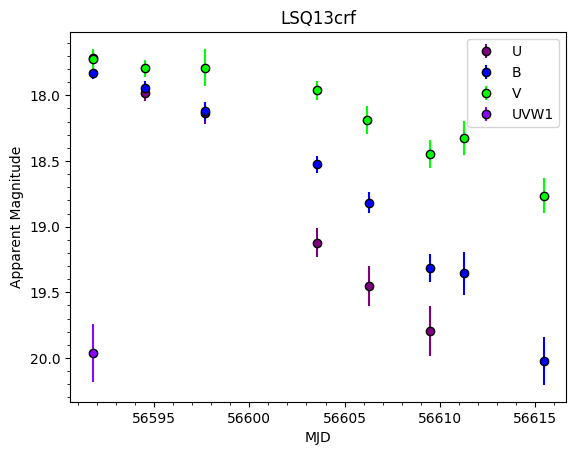

Skip? (y/n) y


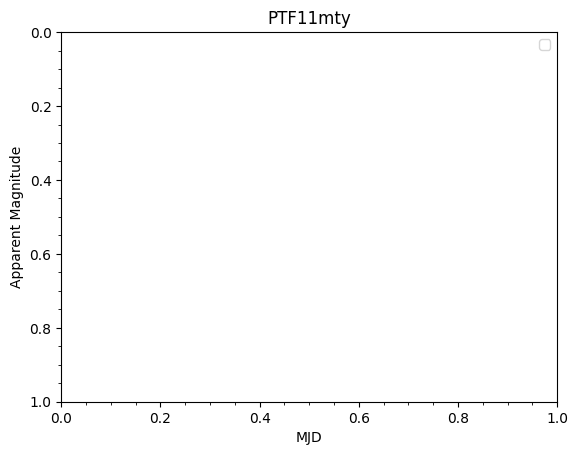

Skip? (y/n) y


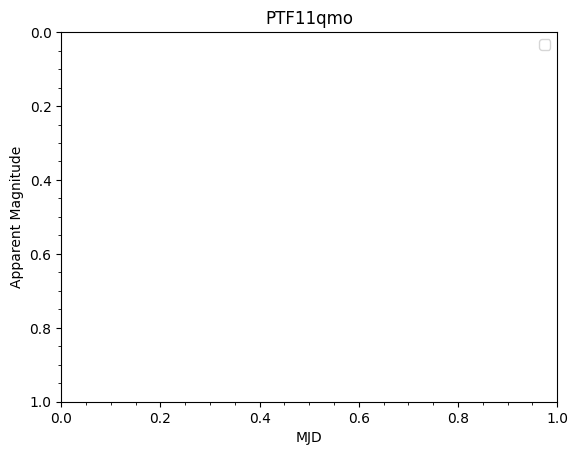

Skip? (y/n) y


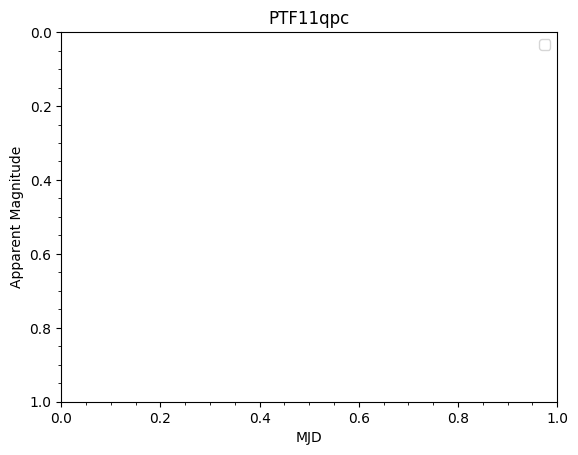

Skip? (y/n) y


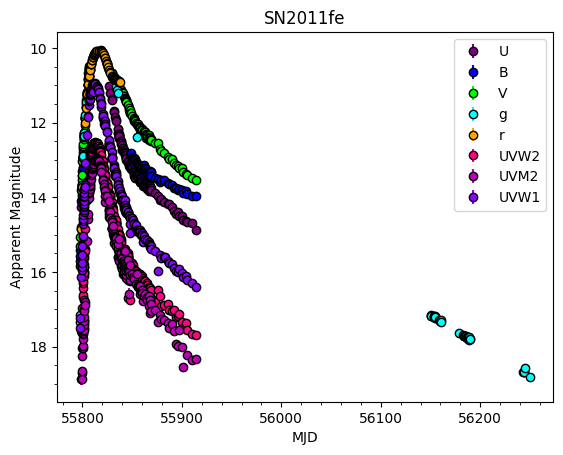

Skip? (y/n) y


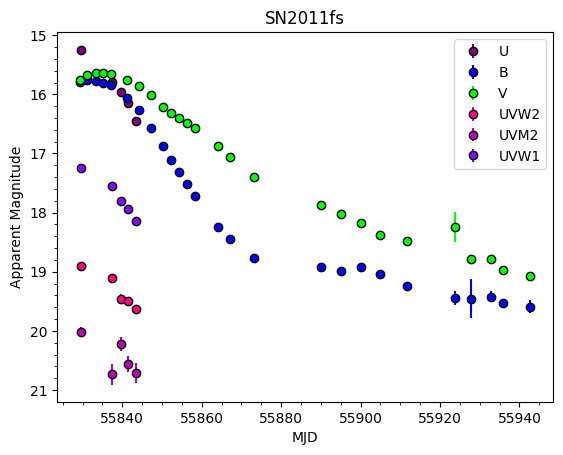

Skip? (y/n) n
Filter to find peak in: V
Window of days to find peak in: 20


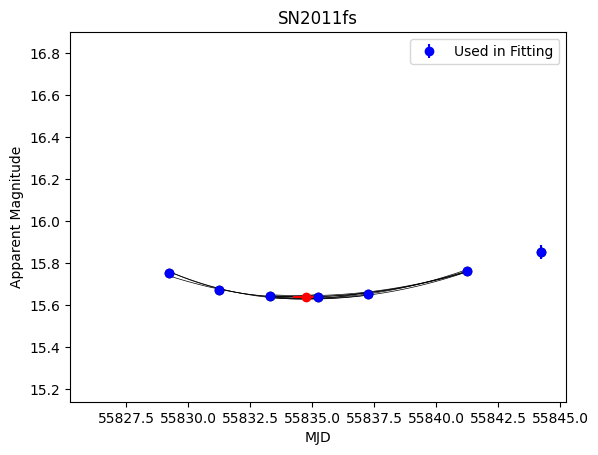

Looks good? (y/n) y


['SN2011fs_datacube_mangled.csv', 'SN2011fs_uvotB15.1.dat', 'SN2011fs_asassn_raw.dat', 'SN2011fs_data.json', 'SN2011fs_opensn.json']


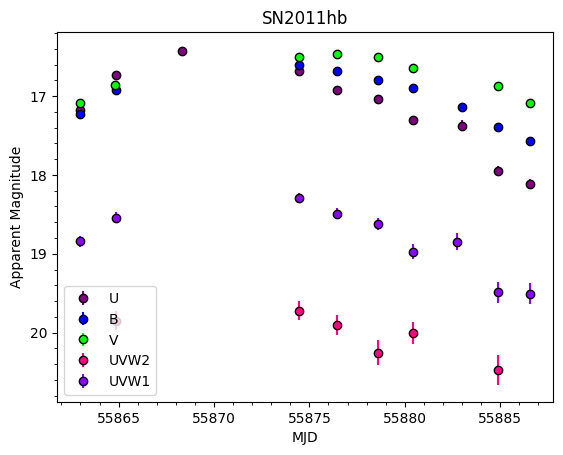

Skip? (y/n) n
Filter to find peak in: V
Window of days to find peak in: 25


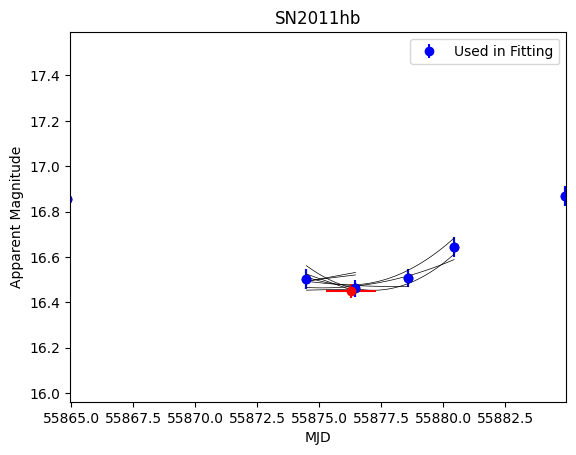

Looks good? (y/n) y


['SN2011hb_data.json', 'SN2011hb_datacube_mangled.csv']


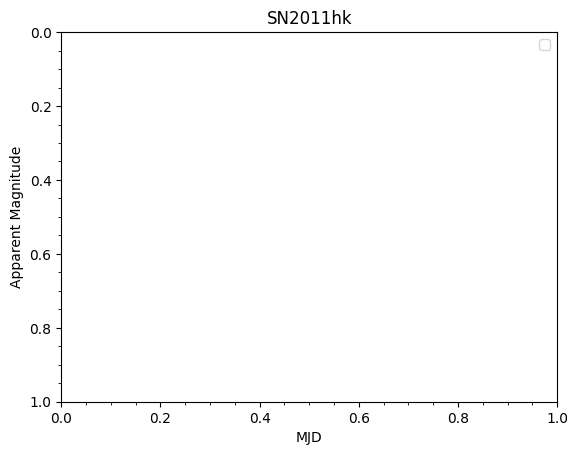

Skip? (y/n) y


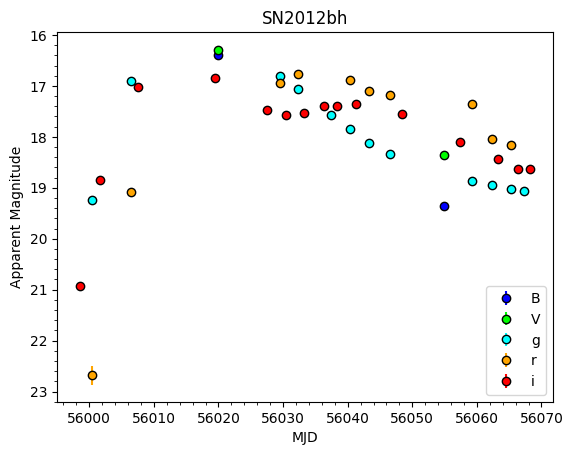

Skip? (y/n) y


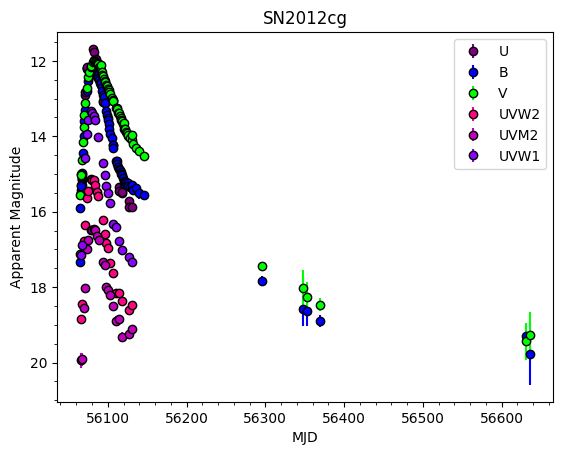

Skip? (y/n) n
Filter to find peak in: V
Window of days to find peak in: 10


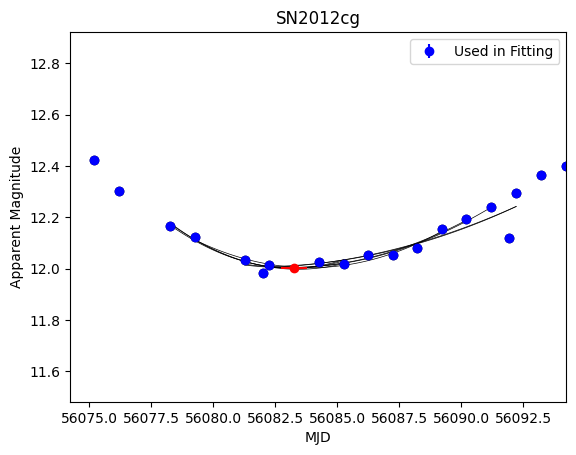

Looks good? (y/n) y


['SN2012cg_datacube_mangled.csv', 'SN2012cg_uvotB15.1.dat', 'SN2012cg_data.json', 'SN2012cg_asassn_raw.dat', 'SN2012cg_opensn.json']


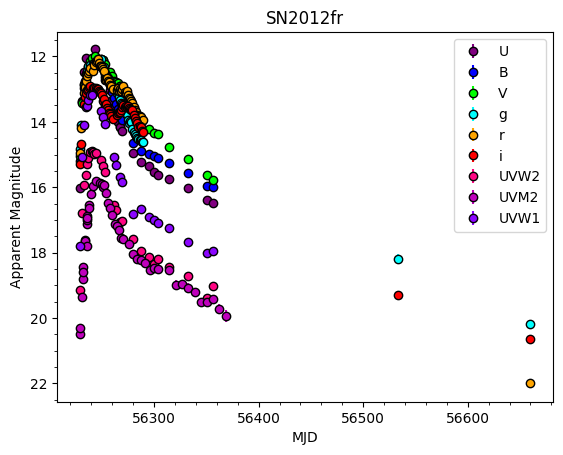

Skip? (y/n) n
Filter to find peak in: r
Window of days to find peak in: 10


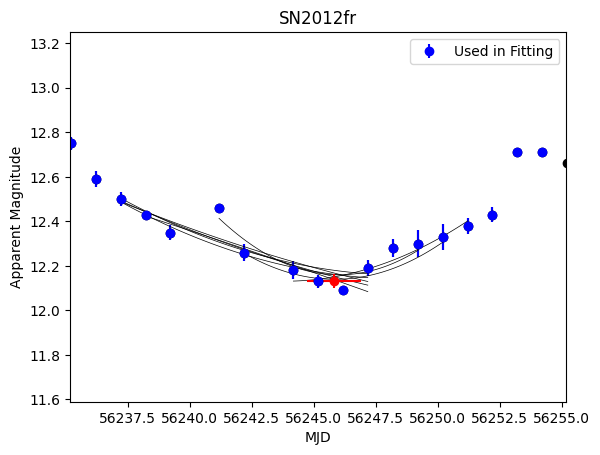

Looks good? (y/n) y


['SN2012fr_data.json', 'SN2012fr_datacube_mangled.csv', 'SN2012fr_uvotB15.1.dat', 'SN2012fr_asassn_raw.dat', 'SN2012fr_opensn.json']


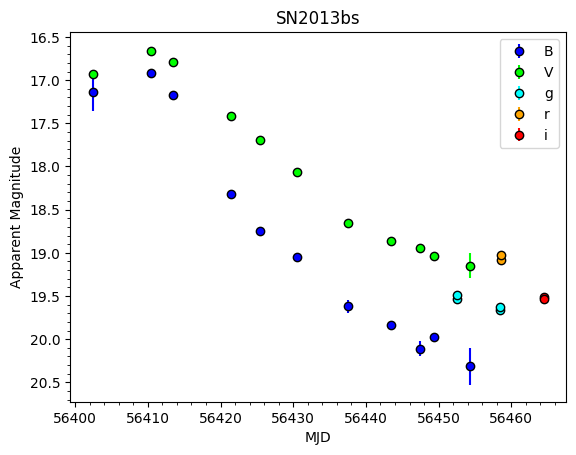

Skip? (y/n) y


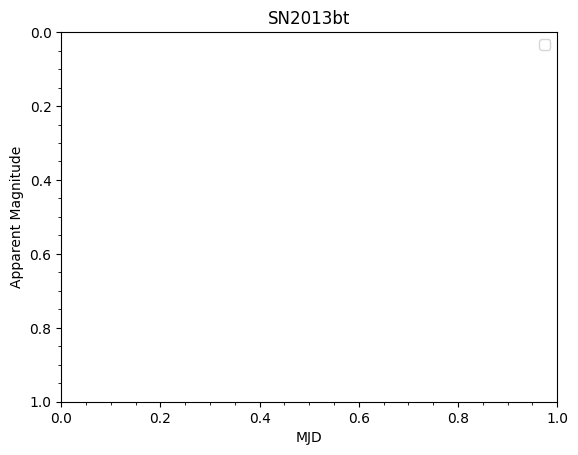

Skip? (y/n) y


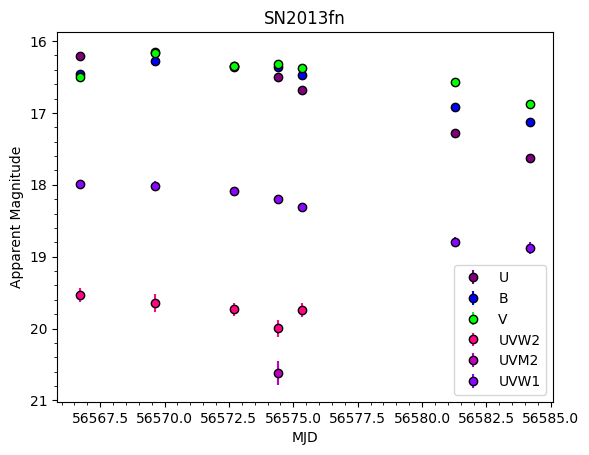

Skip? (y/n) n
Filter to find peak in: V
Window of days to find peak in: 10


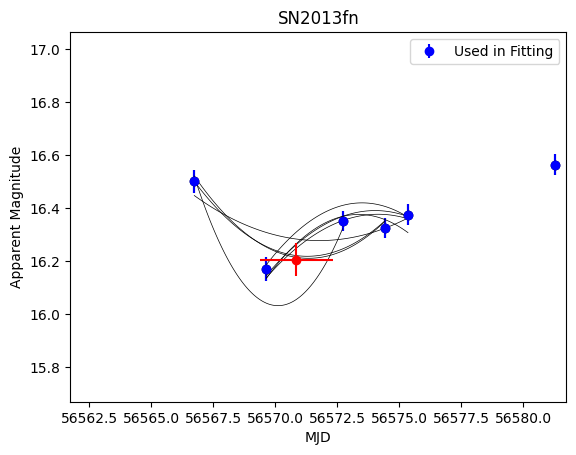

Looks good? (y/n) y


['SN2013fn_datacube_mangled.csv', 'SN2013fn_data.json', 'SN2013fn_opensn.json', 'SN2013fn_uvotB15.1.dat']


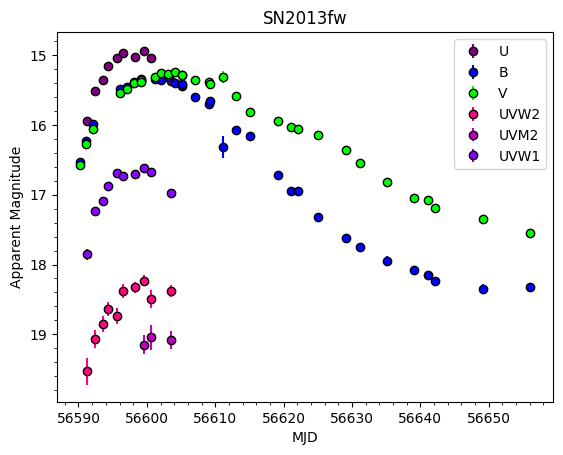

Skip? (y/n) n
Filter to find peak in: V
Window of days to find peak in: 20


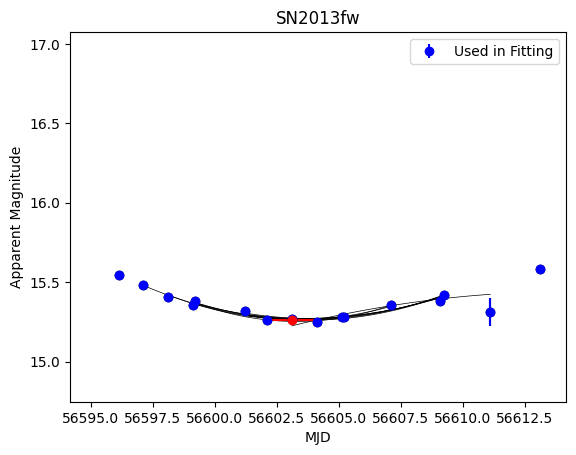

Looks good? (y/n) y


['SN2013fw_data.json', 'SN2013fw_datacube_mangled.csv']


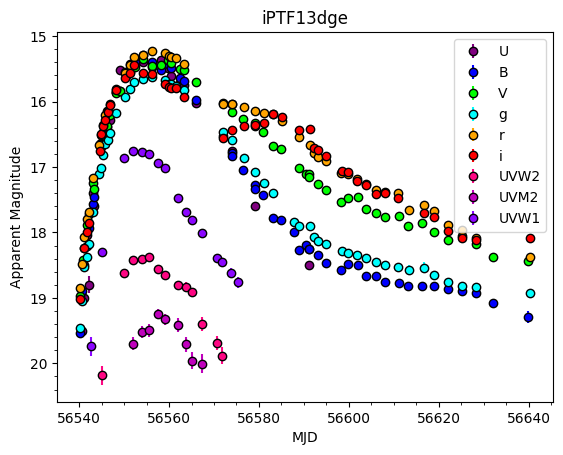

Skip? (y/n) n
Filter to find peak in: r
Window of days to find peak in: 10


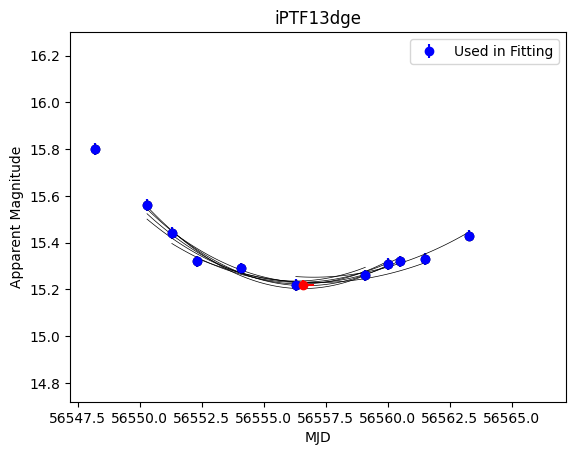

Looks good? (y/n) y


['iPTF13dge_datacube_mangled.csv', 'iPTF13dge_data.json']


In [7]:
for name in SNe:
    filepath = f"/lustre/lrspec/users/4300/cube/Data/Phot/{name}dict.pkl"
    with open(filepath, 'rb') as f:
        SN_infos = pickle.load(f)
        SN_datas = pickle.load(f)
        SN_names = pickle.load(f)  
    new_sn = SN(
        name= SN_names[0],
        data= SN_datas[0],
        type = "Other",
        subtype ="SNIa",
        info= SN_infos[0],
    )
    new_sn.plot_data()
    plt.show()
    skip = input("Skip? (y/n)")
    if skip == "y":
        continue
    else: 
        filt = input("Filter to find peak in:")
        window = input("Window of days to find peak in:")
        new_sn.fit_for_max(filt = filt,plot=True, window = int(window))
        plt.show()
        looks_good = input("Looks good? (y/n)")
        if looks_good == 'y':
            new_sn.write_info_to_caat_file(force = True)
            new_sn.write_json_data(dry_run = False)
            cube = DataCube(sn=new_sn)
            cube.measure_flux_in_filter(save=True)
            print(os.listdir(f"/home/4300/miniconda3/envs/gopreaux/lib/python3.10/site-packages/caat/data/Other/SNIa/{name}"))
        else:
            continue

In [5]:
SweetSpotNames = []
for name in SS_info["Name"]:
    try:
        print(os.listdir(f"/home/4300/miniconda3/envs/gopreaux/lib/python3.10/site-packages/caat/data/Other/SNIa/{name}"))
    except FileNotFoundError:
        continue
    SweetSpotNames.append(name)
print(len(SweetSpotNames))

['LSQ12fuk_datacube_mangled.csv', 'LSQ12fuk_data.json']
['LSQ12gef_datacube_mangled.csv', 'LSQ12gef_data.json']
['LSQ13crf_data.json', 'LSQ13crf_datacube_mangled.csv']
['SN2011fe_datacube_mangled.csv', 'SN2011fe_opensn.json', 'SN2011fe_uvotB15.1.dat', 'SN2011fe_asassn_raw.dat']
['SN2011fs_datacube_mangled.csv', 'SN2011fs_uvotB15.1.dat', 'SN2011fs_asassn_raw.dat', 'SN2011fs_data.json', 'SN2011fs_opensn.json']
['SN2011hb_data.json', 'SN2011hb_datacube_mangled.csv']
['SN2011iy_uvotB15.1.dat', 'SN2011iy_opensn.json', 'SN2011iy_asassn_raw.dat']
['SN2012bh_data.json', 'SN2012bh_datacube_mangled.csv']
['SN2012cg_datacube_mangled.csv', 'SN2012cg_uvotB15.1.dat', 'SN2012cg_data.json', 'SN2012cg_asassn_raw.dat', 'SN2012cg_opensn.json']
['SN2012fr_data.json', 'SN2012fr_datacube_mangled.csv', 'SN2012fr_uvotB15.1.dat', 'SN2012fr_asassn_raw.dat', 'SN2012fr_opensn.json']
['SN2013bs_data.json', 'SN2013bs_datacube_mangled.csv']
['SN2013fn_datacube_mangled.csv', 'SN2013fn_data.json', 'SN2013fn_opensn.jso

In [28]:
SweetSpotNames = os.listdir(f"/home/4300/miniconda3/envs/gopreaux/lib/python3.10/site-packages/caat/data/Other/SNIa/")
print(SweetSpotNames)


['SN2021low', 'SN2017cfd', 'SN2017jl', 'SN2011iv', 'SN2022hrs', 'SN2018zz', 'SN2020ftl', 'SN2020dhj', 'SN2008ge', 'SN2023hzy', 'SN2011B', 'SN2017jdx', 'SN2011dn', 'SN2018bi', 'SN2021skf', 'SN2018feb', 'SN2020qic', 'SN2020rgz', 'SN2019ein', 'SN2021K', 'SN2017gxq', 'SN2021ghc', 'SN2019odh', 'SN2016gfr', 'SN2018hpu', 'SN2021zfw', 'SN2023gft', 'SN2017fvl', 'SN2011fe', 'SN2012fr', 'SN2017hm', 'SN2007cq', 'SN2007co', 'SN2017hbf', 'LSQ12gef', 'SN2008hv', 'SN2016coj', 'SN2020ssf', 'SN2021aefx', 'SN2017cjr', 'SN2017iyw', 'SN2020kyx', 'SN2016asf', 'SN2020dul', 'SN2022ssk', 'SN2011by', 'SN2023huy', 'SN2017gup', 'SN2018jov', 'SN2023jvu', 'SN2021mim', 'SN2011ao', 'SN2023ftr', 'SN2017izu', 'SN2020nlb', 'SN2022dmf', 'SN2020acma', 'SN2016fff', 'SN2013aa', 'SN2014bv', 'SN2018jky', 'SN2018gv', 'SN2017gjn', 'SN2014I', 'SN2017ckq', 'SN2018yu', 'SN2016ito', 'SN2022pul', 'SN2017cbr', 'SN2018pv', 'SN2016hht', 'SN2019bqe', 'SN2013dy', 'SN2012cg', 'SN2006E', 'SN2023ext', 'SN2023hsw', 'SN2017dhr', 'SN2018ph', '

In [6]:
print(SweetSpotNames)

['LSQ12fuk', 'LSQ12gef', 'LSQ13crf', 'SN2011fe', 'SN2011fs', 'SN2011hb', 'SN2011iy', 'SN2012bh', 'SN2012cg', 'SN2012fr', 'SN2013bs', 'SN2013fn', 'SN2013fw', 'iPTF13dge']


[2.97007368 0.26751849]


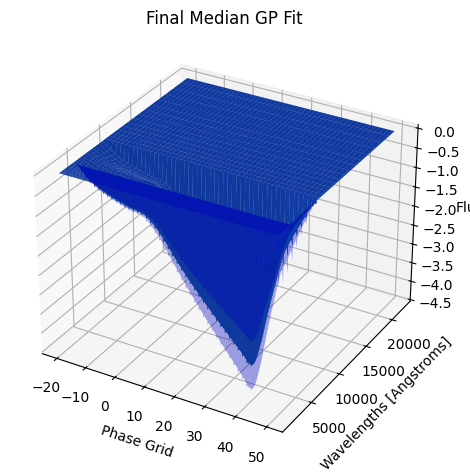

LSQ12fuk done!
[3.         2.55420379]


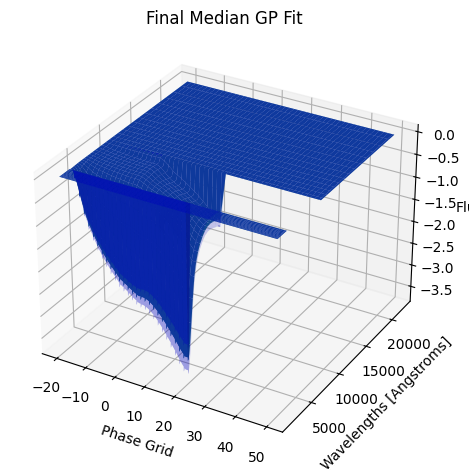

LSQ12gef done!
[3.         0.24900061]


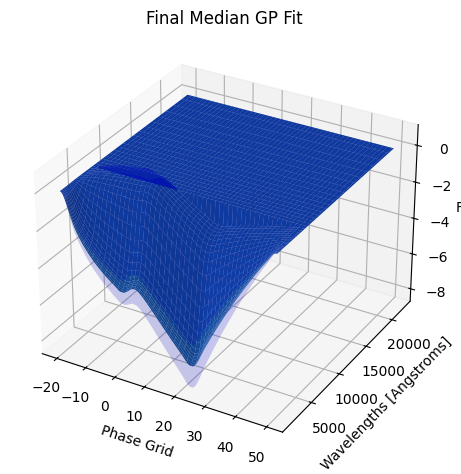

LSQ13crf done!
[0.95989369 0.14607605]


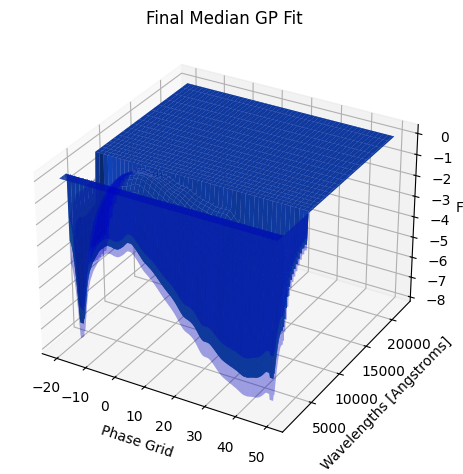

SN2011fe done!
[0.81971683 0.34002126]


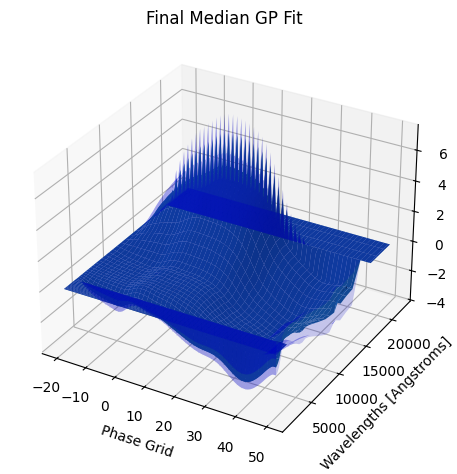

SN2011fs done!
[1.16415478 0.24068633]


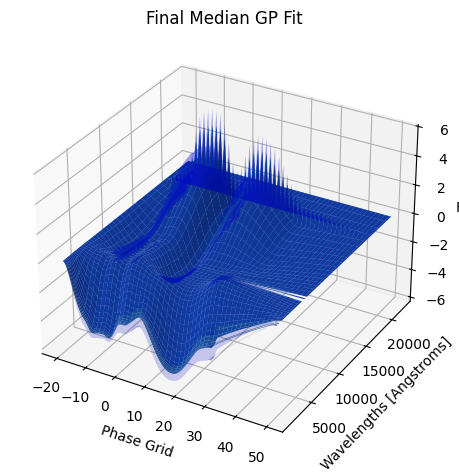

SN2011hb done!
SN2011iy returns error "list index out of range" during optimize parameters
[1.16415478 0.24068633]
SN2011iy had error during modeling
[1.26033839 0.10381471]


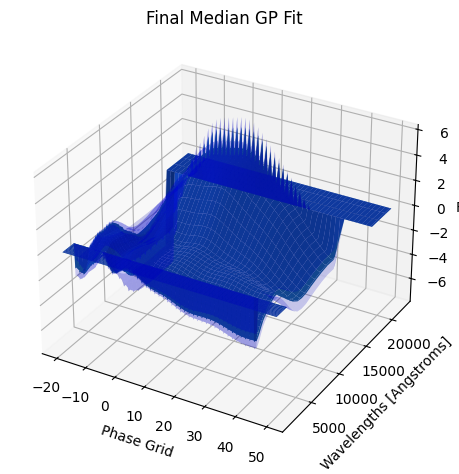

SN2012bh done!
[1.12807217 0.20399282]


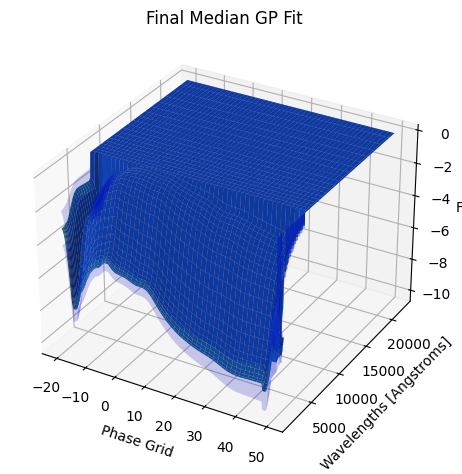

SN2012cg done!
[0.85324831 0.1       ]


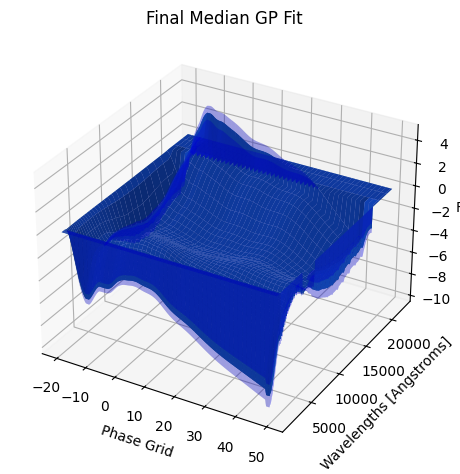

SN2012fr done!
[1.09056135 0.11903738]


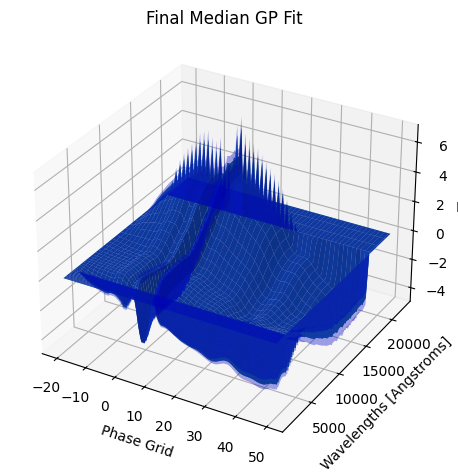

SN2013bs done!
SN2013fn returns error "list index out of range" during optimize parameters
[1.09056135 0.11903738]
SN2013fn had error during modeling
[3.         0.10725546]


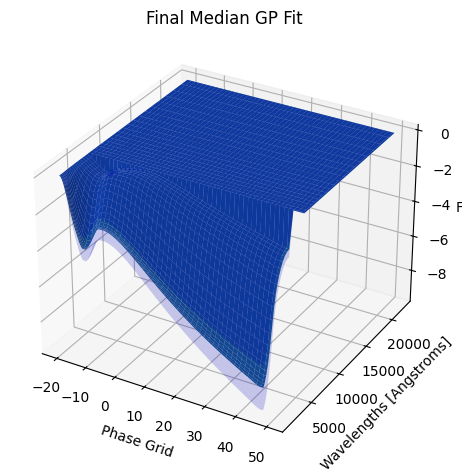

SN2013fw done!
[1.7236257  0.10894092]


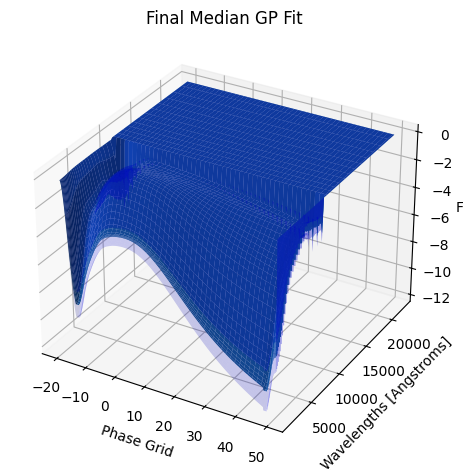

iPTF13dge done!


In [7]:
models = []

kernel = RBF([np.log(10.0), np.log10(500.0)], (0.1, 3.0))
sn_to_normalize = SNCollection(sntype="Other", snsubtype = "SNIa")
filts = ['UVW2', 'UVM2', 'UVW1', 'U', 'B', 'g', 'c', 'V', 'r', 'o', 'i','z','y','J','H','K']
phasemin = -20
phasemax = 50
log_transform = 22
mangle_sed = True

for name in SweetSpotNames:
    sn_type = SNCollection([name])
    kernel = RBF([np.log(10.0), np.log10(500.0)], (0.1, 3.0))
    
    gp = GP3D(
        sn_type, 
        kernel, 
        filts,
        phasemin, 
        phasemax,
        set_to_normalize=sn_to_normalize,
        log_transform=log_transform,
        mangle_sed=mangle_sed
    )
    try:
        kernel_parameters = gp.optimize_hyperparams(subtract_polynomial=True)
    except ValueError:
        print(f'{name} has weird kernel')
    except IndexError:
        print(f'{name} returns error "list index out of range" during optimize parameters')
    # Let's look at the kernel hyperparameters
    optimized_kernel_hyperparams = np.asarray([np.median([k[i] for k in kernel_parameters]) for i in range(len(kernel_parameters[0]))])
    print(np.exp(optimized_kernel_hyperparams))
    if len(np.exp(optimized_kernel_hyperparams)) > 1:
        try:
            model = gp.predict(
                plot=False,
                subtract_polynomial=True,
            ) 
            print(f"{name} done!")
            models.append(model)
        except ValueError:
            print(f"{name} had error during modeling")
            continue
    else:
        print(f'{name} is weird')
        continue

In [8]:
print(models)

In [8]:
band_wl_dict = {"u":3600,
                "g":5000,
                "r":6400,
                "i":7800,
                "z":8600,
                "Y":9800
               }

In [9]:
print(list(band_wl_dict))
print(band_wl_dict[list(band_wl_dict)[0]])

['u', 'g', 'r', 'i', 'z', 'Y']
3600


In [25]:
ObjInterps = {'u': [], 'g': [], 'r': [], 'i': [], 'z': [], 'Y': []}
TimeRange = {'u': [], 'g': [], 'r': [], 'i': [], 'z': [], 'Y': []}
for model in models:
    # ObjInterps = {'u': [], 'g': [], 'r': [], 'i': [], 'z': [], 'Y': []}
    # TimeRange = {'u': [], 'g': [], 'r': [], 'i': [], 'z': [], 'Y': []}
    print(model.collection.sne[0])
    model.surface.iqr = np.abs(model.surface.iqr)
    try:
        for filt in list(band_wl_dict):
            wl = band_wl_dict[filt]
            times_wl = np.arange(-10,40,0.1)
            wls = np.full(len(times_wl),wl)
            phases, pred, dev = model.predict_photometry_points(wls,times_wl)
            interp = make_smoothing_spline(phases, pred)
            ObjInterps[filt].append(interp)
            TimeRange[filt].append([phases[0],phases[-1]])
            EventName = "SweetSpot_"+model.collection.sne[0].name
    except ValueError:
        print("Error",len(ObjInterps))
        continue
with open(f'/lustre/lrspec/users/4300/cube/Data/Interp/SweetSpot_Interp.pkl', 'wb') as f:
    pickle.dump(ObjInterps, f)
    pickle.dump(TimeRange, f)

LSQ12fuk
LSQ12gef
Error 6
LSQ13crf
SN2011fe
SN2011fs
SN2011hb
Error 6
SN2012bh
Error 6
SN2012cg
SN2012fr
SN2013bs
SN2013fw
iPTF13dge


In [29]:
PathInterp = '/lustre/lrspec/users/4300/cube/Data/Interp'
EventName = 'CAATSNIa'
FilePath = os.path.join(PathInterp, EventName+'_Interp.pkl')
with open(FilePath, 'rb') as f:
    Interp_load = pickle.load(f)
    TimeRange_load = pickle.load(f)

In [30]:
TimeRangeStart = max( TimeRange_load['u'][0][0], TimeRange_load['g'][0][0] - 90/1440 )
TimeRangeEnd = min( TimeRange_load['u'][0][1] - 30/1440, TimeRange_load['g'][0][1] - 90/1440 )

TimeRange = TimeRangeEnd - TimeRangeStart
SampleNo = int(100*TimeRange)

XX = np.random.rand(SampleNo)*TimeRange + TimeRangeStart
print(XX)

[35.99411468  5.78602679 -5.00291357 ... 26.04607611 23.58278924
 -3.93697365]


In [47]:
len(Interp_load['u'])

206

In [58]:
sn_type = SNCollection(["SN2013bs"])
#SNCollection(sntype="Other", snsubtype="SNIa")

kernel = RBF([np.log(10.0), np.log10(500.0)], (0.1, 3.0))

# The normalization set provides photometry used to construct residuals, which are then fit
#sn_to_normalize = SNCollection(sntype="SNII", snsubtype="SNII")
sn_to_normalize = SNCollection(sntype="Other", snsubtype = "SNIa")

#filts = ['g','r','i','B','V']
#filts = [np.str_('B'), np.str_('H'), np.str_('I'), np.str_('J'), np.str_('R'), np.str_('V'), np.str_('g'), np.str_('i'), np.str_('r'), np.str_('z')]
filts = ['UVW2', 'UVM2', 'UVW1', 'U', 'B', 'g', 'c', 'V', 'r', 'o', 'i','z','y','J','H','K']
phasemin = -20
phasemax = 50
log_transform = 22
mangle_sed = True

gp = GP3D(
    sn_type, 
    kernel, 
    filts,
    phasemin, 
    phasemax,
    set_to_normalize=sn_to_normalize,
    log_transform=log_transform,
    mangle_sed=mangle_sed
)

In [59]:
kernel_parameters = gp.optimize_hyperparams(subtract_polynomial=True)

# Let's look at the kernel hyperparameters
optimized_kernel_hyperparams = np.asarray([np.median([k[i] for k in kernel_parameters]) for i in range(len(kernel_parameters[0]))])
print(np.exp(optimized_kernel_hyperparams))

[1.09056135 0.11903738]


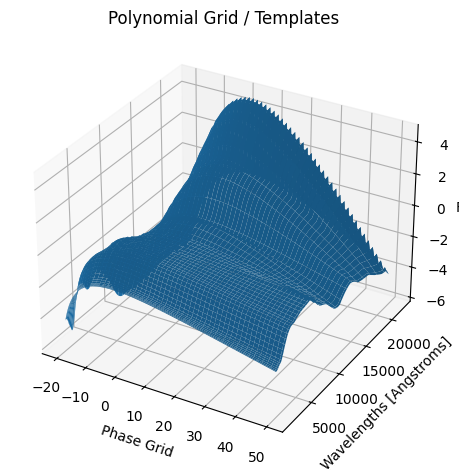

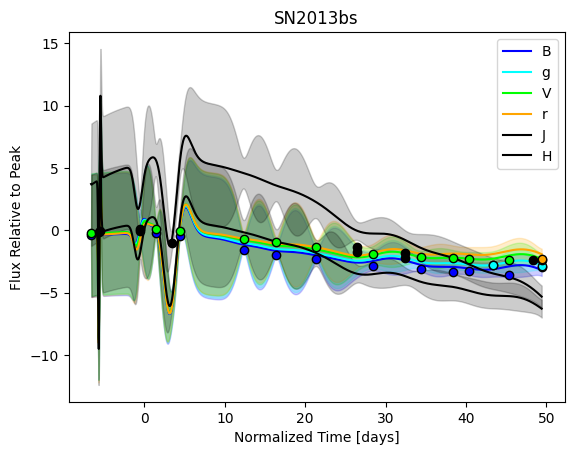

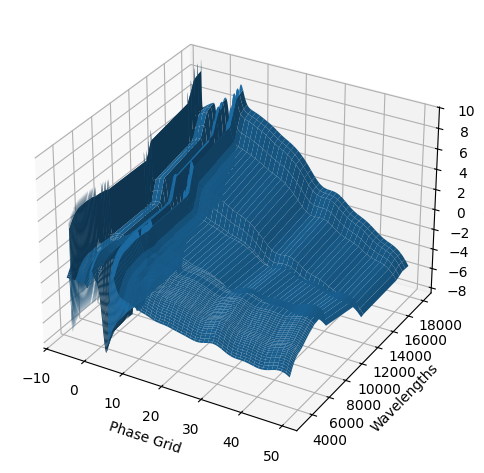

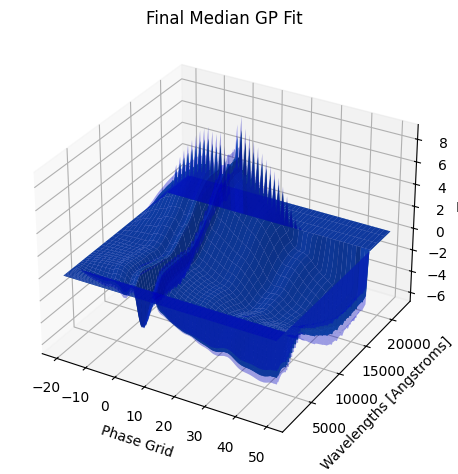

In [60]:
%matplotlib inline
sn2013bsmodel = gp.predict(
    plot=True,
    subtract_polynomial=True,
)

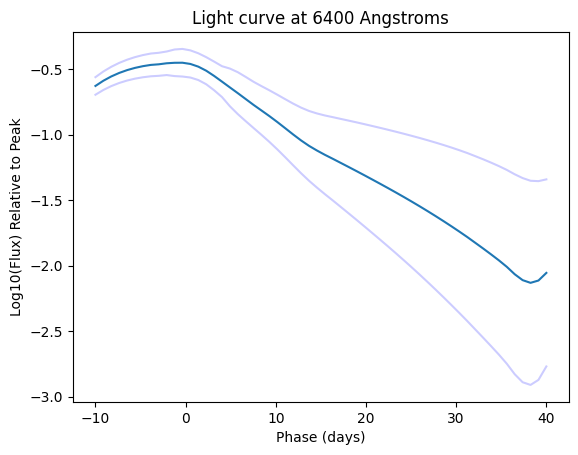

In [9]:
#sn2013bsmodel.predict_lightcurve(-5, 45.0, 5000)
models[0].predict_lightcurve(-10, 40.0, 6400)

In [22]:
10**SweetSpotModel.surface.wl_grid

array([ 1530.        ,  1565.63827819,  1602.10667852,  1639.42453701,
        1677.6116401 ,  1716.68823508,  1756.67504089,  1797.59325906,
        1839.46458496,  1882.31121934,  1926.15588005,  1971.02181409,
        2016.93280999,  2063.91321037,  2111.98792484,  2161.18244327,
        2211.52284924,  2263.0358339 ,  2315.74871011,  2369.68942694,
        2424.88658447,  2481.36944896,  2539.16796838,  2598.31278827,
        2658.83526799,  2720.76749736,  2784.14231367,  2848.99331909,
        2915.35489848,  2983.26223763,  3052.7513419 ,  3123.85905534,
        3196.62308021,  3271.08199694,  3347.27528464,  3425.24334201,
        3505.02750873,  3586.67008744,  3670.2143661 ,  3755.704641  ,
        3843.18624021,  3932.70554764,  4024.3100276 ,  4118.04825001,
        4213.96991611,  4312.12588483,  4412.56819978,  4515.3501168 ,
        4620.52613221,  4728.15201175,  4838.28482006,  4950.98295102,
        5066.30615868,  5184.31558893,  5305.07381192,  5428.64485527,
      

In [46]:
#I need to make an array
dT1 = (1/24)*1.5 #90 min
dT2 = (1/24)*0.5 #30 min
wl1 = 5000
wl2 = 6400
times_wl1 = np.arange(-10,40, dT1)
times_wl2 = np.arange(-10,40,dT1)+dT2
phases = np.concatenate((times_wl1,times_wl2), axis=None)
wl1s = np.full(len(times_wl1),wl1)
wl2s = np.full(len(times_wl2),wl2)
wls = np.concatenate((wl1s,wl2s),axis=None)
phase_wl_array = np.vstack((phases, wls)).T

In [11]:
#I need to make an array
dT1 = (1/24)*1.5 #90 min
dT2 = (1/24)*0.5 #30 min
wl1 = 5000
wl2 = 6400
times_wl1 = np.arange(-10,40,0.1)
times_wl2 = np.arange(-10,40,0.1)
phases = np.concatenate((times_wl1,times_wl2), axis=None)
wl1s = np.full(len(times_wl1),wl1)
wl2s = np.full(len(times_wl2),wl2)
wls = np.concatenate((wl1s,wl2s),axis=None)
phase_wl_array = np.vstack((np.log10(phases),np.log10(wls))).T

In [12]:
phases, pred, dev = models[0].predict_photometry_points(wl1s,times_wl1, show = True)

ValueError: scale < 0

In [115]:
from scipy.interpolate import RegularGridInterpolator, CubicSpline, make_smoothing_spline

interp = make_smoothing_spline(phases, pred)

In [104]:
peak_mag = sn2013bsmodel.collection.sne[0].info["peak_mag"]

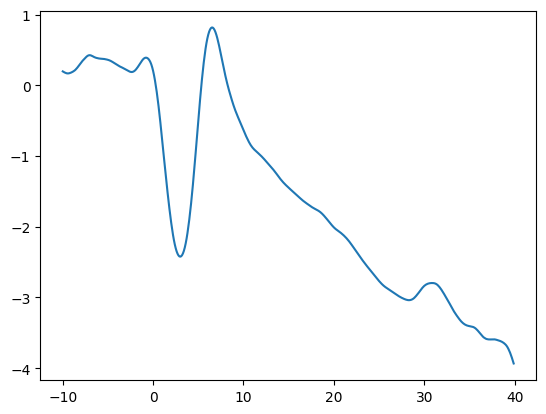

In [116]:
plt.plot(times_wl1,interp(times_wl1))

In [132]:
sn2013bsmodel.collection.sne[0].name

'SN2013bs'